========== Dataset Summary ==========
Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)


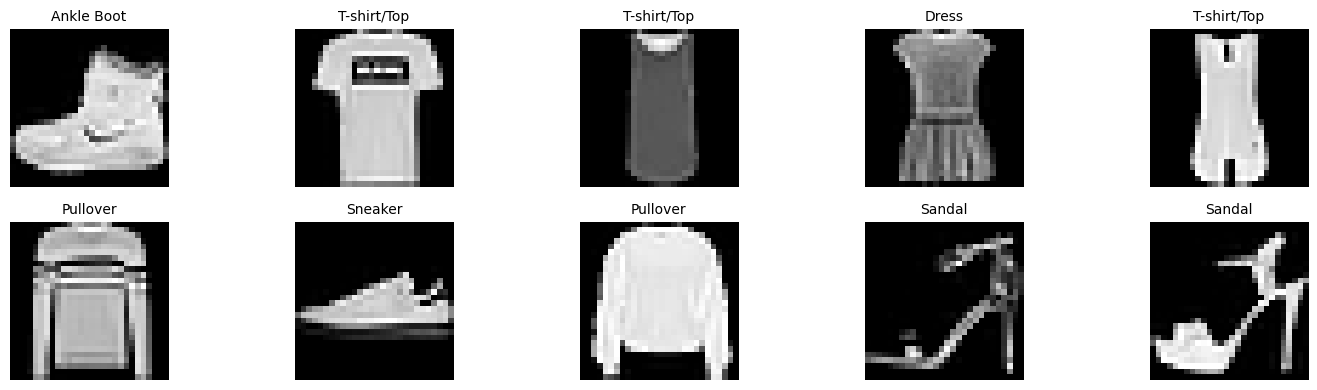

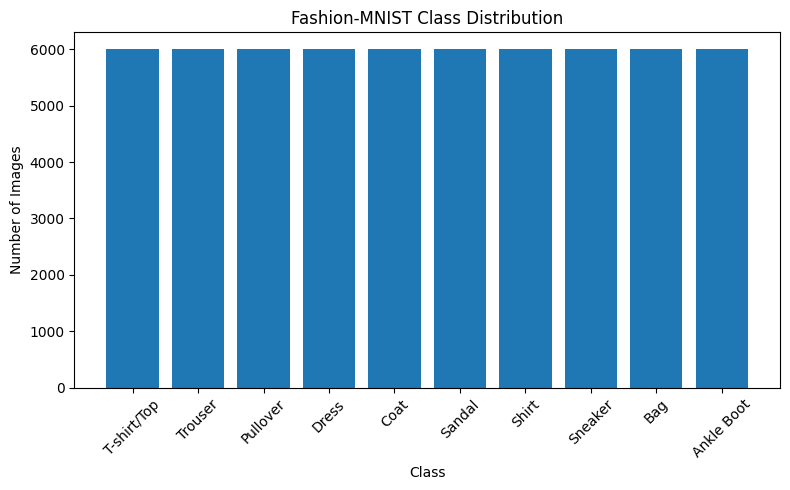

In [ ]:
# ==========================================
# Task 1 : Dataset Exploration
# ==========================================

# Import required libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load Fashion-MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Print dataset dimensions
print("========== Dataset Summary ==========")
print("Training Images Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)
print("Testing Images Shape  :", X_test.shape)
print("Testing Labels Shape  :", y_test.shape)

# Class names
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

# ------------------------------------------
# Display 10 Sample Images
# ------------------------------------------

plt.figure(figsize=(15,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]], fontsize=10)
    plt.axis('off')

plt.tight_layout()

# Save figure
plt.savefig("dataset_samples.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

# ------------------------------------------
# Plot Class Distribution
# ------------------------------------------

unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8,5))

plt.bar(class_names, counts)

plt.title("Fashion-MNIST Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.tight_layout()

# Save figure
plt.savefig("class_distribution.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

In [ ]:
# Task 2 : Data Preprocessing
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


# Class names
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]



In [ ]:
# Print Shapes Before Preprocessing
print("========== BEFORE PREPROCESSING ==========")
print("Training Images Shape :", X_train.shape)
print("Testing Images Shape  :", X_test.shape)
print("Training Labels Shape :", y_train.shape)
print("Testing Labels Shape  :", y_test.shape)


========== BEFORE PREPROCESSING ==========
Training Images Shape : (60000, 28, 28)
Testing Images Shape  : (10000, 28, 28)
Training Labels Shape : (60000,)
Testing Labels Shape  : (10000,)


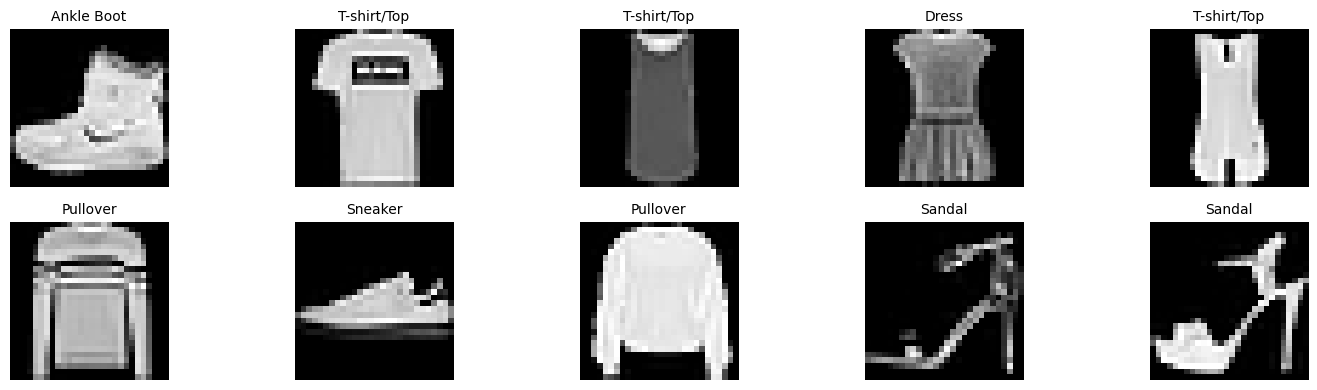

In [ ]:
# Display Sample Images
plt.figure(figsize=(15, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]], fontsize=10)
    plt.axis("off")

plt.tight_layout()

# Save image
plt.savefig("preprocessing_sample_images.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

In [ ]:
# Flatten Images
# (60000,28,28) --> (60000,784)
X_train = X_train.reshape(X_train.shape[0], 28 * 28)
X_test = X_test.reshape(X_test.shape[0], 28 * 28)

In [ ]:
# Normalize Pixel Values
# Pixel Range : 0-255 --> 0-1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [ ]:
# One-Hot Encode Labels
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [ ]:
# Print Shapes After Preprocessing
print("\n========== AFTER PREPROCESSING ==========")
print("Training Images Shape :", X_train.shape)
print("Testing Images Shape  :", X_test.shape)
print("Training Labels Shape :", y_train.shape)
print("Testing Labels Shape  :", y_test.shape)


========== AFTER PREPROCESSING ==========
Training Images Shape : (60000, 784)
Testing Images Shape  : (10000, 784)
Training Labels Shape : (60000, 10)
Testing Labels Shape  : (10000, 10)


In [ ]:
# Display Sample Values
print("\nFirst 10 normalized pixel values of first image:")
print(X_train[0][:10])

print("\nOne-hot encoded label of first training sample:")
print(y_train[0])


First 10 normalized pixel values of first image:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

One-hot encoded label of first training sample:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
# Create the MLP model
model = Sequential()

In [ ]:
# input and 1st hidden layer
model.add(Dense(
    units=128,
    activation='relu',
    input_shape=(784,)
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#second hidden layer
model.add(Dense(
    units=64,
    activation='relu'
))

In [ ]:
#output layer
model.add(Dense(
    units=10,
    activation='softmax'
))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Task4
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8173 - loss: 0.5097 - val_accuracy: 0.8587 - val_loss: 0.3940
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8624 - loss: 0.3766 - val_accuracy: 0.8637 - val_loss: 0.3653
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8745 - loss: 0.3382 - val_accuracy: 0.8726 - val_loss: 0.3564
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8826 - loss: 0.3156 - val_accuracy: 0.8763 - val_loss: 0.3415
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8894 - loss: 0.2979 - val_accuracy: 0.8704 - val_loss: 0.3555
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8956 - loss: 0.2798 - val_accuracy: 0.8744 - val_loss: 0.3506
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8983 - loss: 0.2705 - val_accuracy: 0.8840 - val_loss: 0.3225
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9023 - loss: 0.2585 -

In [ ]:
# Display final training accuracy and loss
print("\n========== Training Complete ==========")
print(f"Final Training Accuracy : {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss : {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss : {history.history['val_loss'][-1]:.4f}")


========== Training Complete ==========
Final Training Accuracy : 0.9336
Final Validation Accuracy : 0.8917
Final Training Loss : 0.1735
Final Validation Loss : 0.3509


In [ ]:
# Task 5
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# Predict probabilities
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert one-hot encoded true labels back to class labels
y_true = np.argmax(y_test, axis=1)

In [ ]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_true, y_pred_classes)
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

print("========== Model Evaluation ==========")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

========== Model Evaluation ==========
Accuracy  : 0.8860
Precision : 0.8890
Recall    : 0.8860
F1-Score  : 0.8866


In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[795   3  13  19   3   1 157   0   9   0]
 [  2 977   2  13   3   0   3   0   0   0]
 [ 21   1 755   7 118   1  96   0   1   0]
 [ 19   9  11 881  35   0  40   0   4   1]
 [  0   1  61  32 838   0  65   0   3   0]
 [  0   0   0   0   0 938   0  38   2  22]
 [ 81   0  49  23  66   0 766   0  15   0]
 [  0   0   0   0   0   5   0 958   1  36]
 [  2   0   1   2   5   1   2   4 983   0]
 [  0   1   0   0   0   4   1  25   0 969]]


In [ ]:
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))


Classification Report:
              precision    recall  f1-score   support

 T-shirt/Top       0.86      0.80      0.83      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.85      0.76      0.80      1000
       Dress       0.90      0.88      0.89      1000
        Coat       0.78      0.84      0.81      1000
      Sandal       0.99      0.94      0.96      1000
       Shirt       0.68      0.77      0.72      1000
     Sneaker       0.93      0.96      0.95      1000
         Bag       0.97      0.98      0.97      1000
  Ankle Boot       0.94      0.97      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [ ]:
# !pip install tensorflow==2.18.0
# !pip install scikeras==0.13.0
# !pip install scikit-learn==1.5.2

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
import numpy as np

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train.reshape(-1, 784).astype("float32") / 255.0
X_test = X_test.reshape(-1, 784).astype("float32") / 255.0

In [ ]:
# !pip install -q scikeras

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [ ]:
def create_model(hidden_layers=1,
                 neurons=128,
                 learning_rate=0.001,
                 optimizer="adam",
                 activation="relu",
                 dropout_rate=0.0):

    model = keras.Sequential()

    model.add(layers.Input(shape=(784,)))

    for _ in range(hidden_layers):
        model.add(layers.Dense(neurons,
                               activation=activation))

        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(10,
                           activation="softmax"))

    if optimizer == "adam":
        opt = keras.optimizers.Adam(learning_rate=learning_rate)

    elif optimizer == "sgd":
        opt = keras.optimizers.SGD(learning_rate=learning_rate)

    else:
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
clf = KerasClassifier(
    model=create_model,
    verbose=0
)

In [ ]:
param_dist = {

    "model__hidden_layers": [1, 2, 3],

    "model__neurons": [32, 64, 128, 256],

    "model__learning_rate": [0.1, 0.01, 0.001],

    "model__optimizer": ["adam", "sgd", "rmsprop"],

    "model__activation": ["relu", "tanh", "sigmoid"],

    "model__dropout_rate": [0.0, 0.2, 0.5],

    "batch_size": [16, 32, 64, 128],

    "epochs": [10, 20, 30]
}

In [ ]:
random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=1
)

In [ ]:
# !pip uninstall -y scikit-learn
# !pip install scikit-learn==1.5.2

In [ ]:
random_search.fit(X_train, y_train_cat)

/usr/local/lib/python3.12/dist-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


RandomizedSearchCV(cv=3,
                   estimator=KerasClassifier(model=<function create_model at 0x7af518cb8540>, verbose=0),
                   n_jobs=1,
                   param_distributions={'batch_size': [16, 32, 64, 128],
                                        'epochs': [10, 20, 30],
                                        'model__activation': ['relu', 'tanh',
                                                              'sigmoid'],
                                        'model__dropout_rate': [0.0, 0.2, 0.5],
                                        'model__hidden_layers': [1, 2, 3],
                                        'model__learning_rate': [0.1, 0.01,
                                                                 0.001],
                                        'model__neurons': [32, 64, 128, 256],
                                        'model__optimizer': ['adam', 'sgd',
                                                             'rmsprop']},
                   random_state=42, scoring='accuracy')

In [ ]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(random_search.best_score_)

Best Parameters:
{'model__optimizer': 'sgd', 'model__neurons': 128, 'model__learning_rate': 0.1, 'model__hidden_layers': 1, 'model__dropout_rate': 0.0, 'model__activation': 'tanh', 'epochs': 30, 'batch_size': 32}

Best Cross Validation Accuracy:
0.8827833333333334


In [ ]:
best_model = random_search.best_estimator_

best_model.fit(X_train, y_train_cat)

KerasClassifier(
	model=<function create_model at 0x7af518cb8540>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=32
	validation_batch_size=None
	verbose=0
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=30
	class_weight=None
	model__optimizer=sgd
	model__neurons=128
	model__learning_rate=0.1
	model__hidden_layers=1
	model__dropout_rate=0.0
	model__activation=tanh
)

In [ ]:
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

print(y_true[:5])
print(y_pred[:5])

y_true shape: (10000,)
y_pred shape: (10000, 10)
[9 2 1 1 6]
[[0 0 0 0 0 0 0 0 0 1]
 [0 0 1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]]


In [ ]:
 print(type(y_true))
print(type(y_pred))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
# Get predictions again
y_pred = best_model.predict(X_test)

# Convert one-hot predictions to class labels
y_pred = np.argmax(y_pred, axis=1)

# Convert true labels to class labels (if using one-hot labels)
y_true = np.argmax(y_test_cat, axis=1)
# OR if you already have the original labels:
# y_true = y_test

In [ ]:
print(y_true.shape)
print(y_pred.shape)
print(y_true[:5])
print(y_pred[:5])

(10000,)
(10000,)
[9 2 1 1 6]
[9 2 1 1 6]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

Accuracy: 0.8892
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1000
           1       0.99      0.98      0.98      1000
           2       0.78      0.85      0.81      1000
           3       0.88      0.90      0.89      1000
           4       0.79      0.84      0.81      1000
           5       0.97      0.95      0.96      1000
           6       0.77      0.65      0.70      1000
           7       0.94      0.96      0.95      1000
           8       0.98      0.97      0.97      1000
           9       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

[[845   2  18  33   9   2  83   0   7   1]
 [  2 978   1  16   3   0   0   0   0   0]
 [ 17   1 849  10  81   0  40   0   2   0]
 [ 14   5  14 897  46   0  21   0   3   0]
 [  1   1  95  26 836   0  40   0   1   0]
 [  0   0

In [ ]:
print(type(best_model))
print(type(best_model.predict(X_test)))
print(best_model.predict(X_test).shape)

<class 'scikeras.wrappers.KerasClassifier'>
<class 'numpy.ndarray'>
(10000, 10)


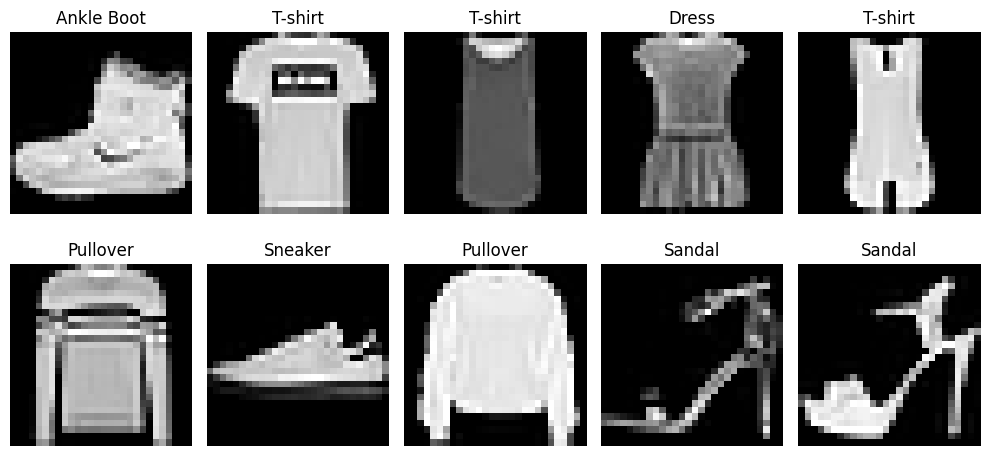

In [ ]:
# Task 8
import matplotlib.pyplot as plt

class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle Boot']

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.savefig("sample_images.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

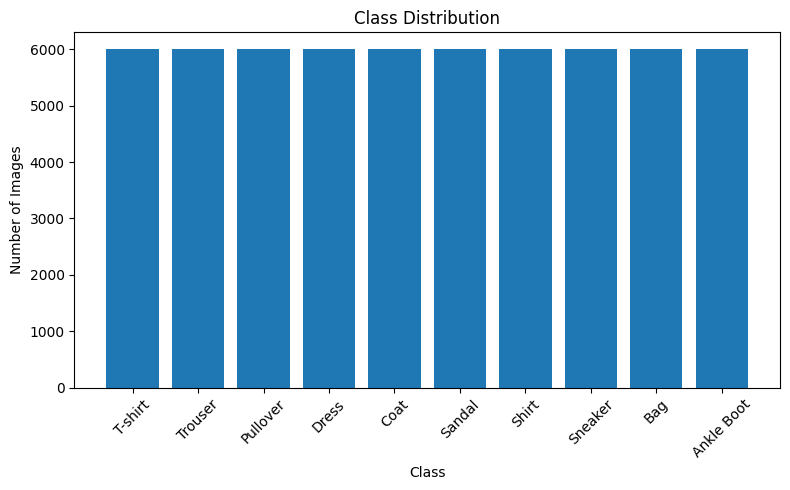

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

classes, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8,5))
plt.bar(class_names, counts)
plt.xticks(rotation=45)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")

plt.tight_layout()
plt.savefig("class_distribution.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

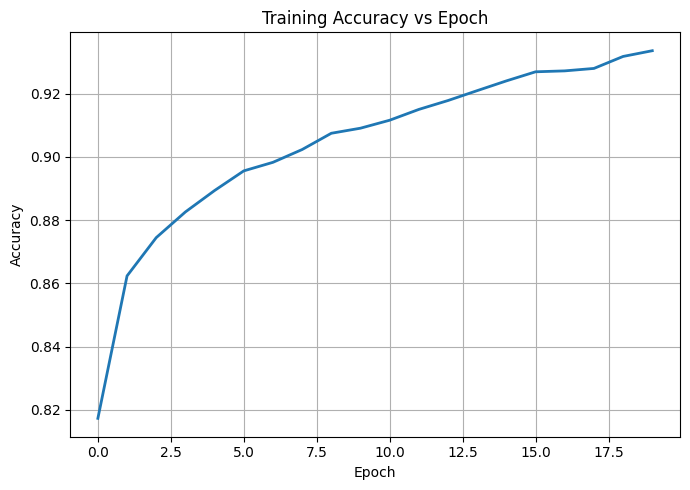

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(history.history['accuracy'], linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epoch")
plt.grid(True)

plt.tight_layout()
plt.savefig("training_accuracy.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

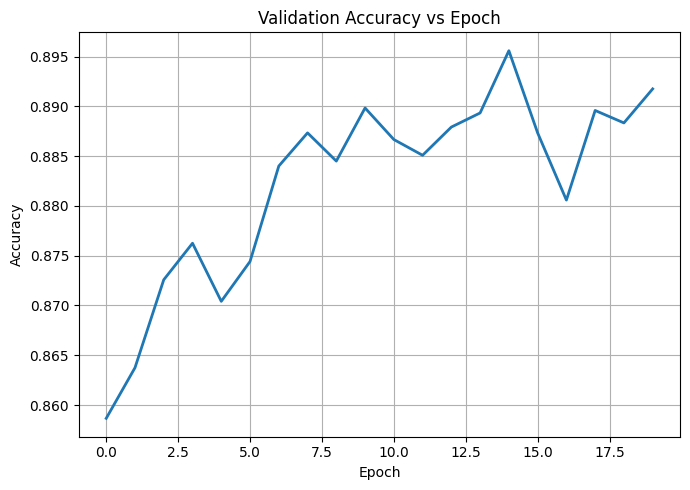

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(history.history['val_accuracy'], linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy vs Epoch")
plt.grid(True)

plt.tight_layout()
plt.savefig("validation_accuracy.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

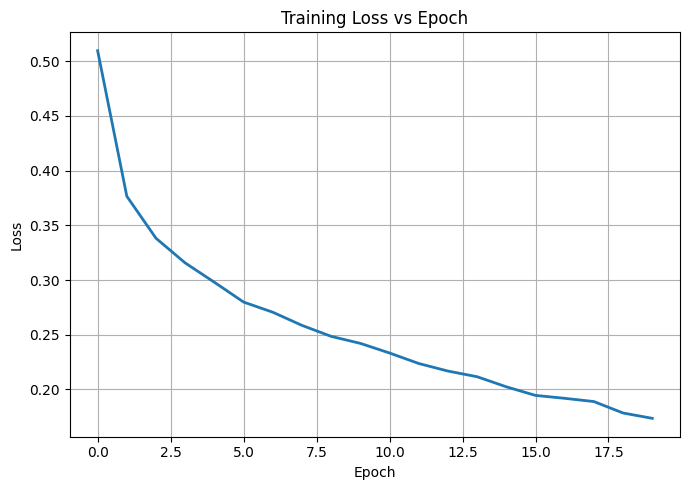

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(history.history['loss'], linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch")
plt.grid(True)

plt.tight_layout()
plt.savefig("training_loss.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

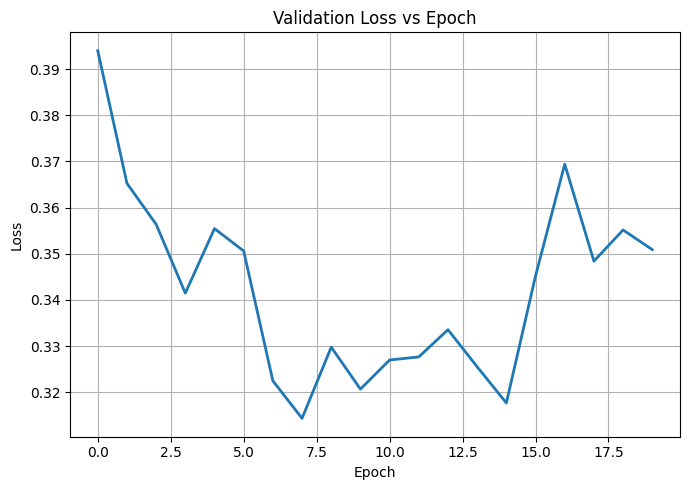

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(history.history['val_loss'], linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss vs Epoch")
plt.grid(True)

plt.tight_layout()
plt.savefig("validation_loss.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

<Figure size 800x800 with 0 Axes>

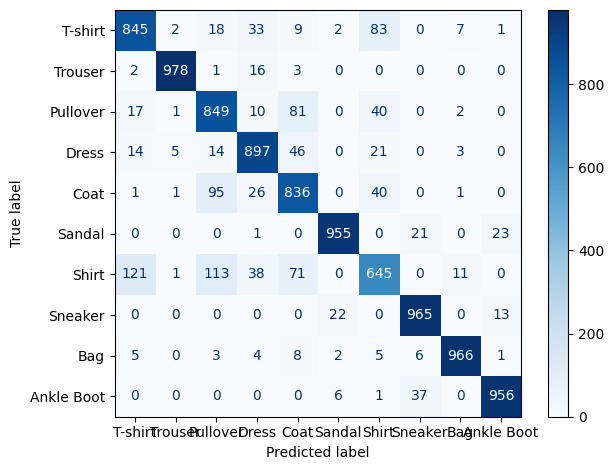

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')

plt.tight_layout()
plt.savefig("confusion_matrix.pdf", dpi=150, bbox_inches="tight")
plt.show()

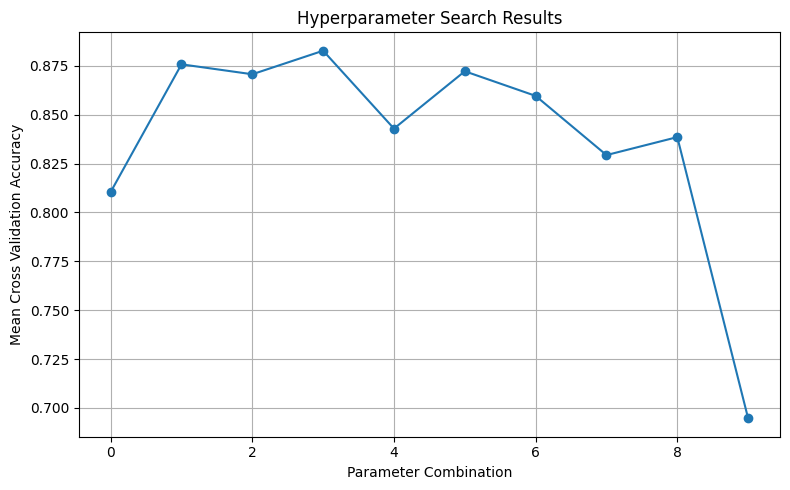

In [ ]:
import matplotlib.pyplot as plt

results = random_search.cv_results_

plt.figure(figsize=(8,5))
plt.plot(results['mean_test_score'], marker='o')
plt.xlabel("Parameter Combination")
plt.ylabel("Mean Cross Validation Accuracy")
plt.title("Hyperparameter Search Results")
plt.grid(True)

plt.tight_layout()
plt.savefig("hyperparameter_search.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [ ]:
test_loss, baseline_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.8859999775886536


In [ ]:
optimized_accuracy = accuracy_score(y_true, y_pred)
print("Optimized Accuracy:", optimized_accuracy)

Optimized Accuracy: 0.8892


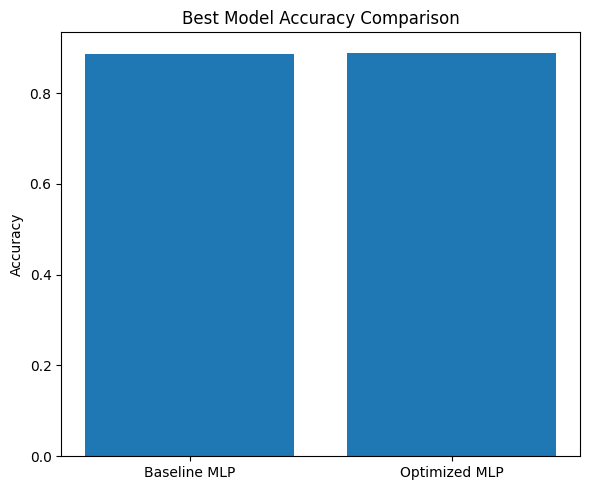

In [ ]:
import matplotlib.pyplot as plt

models = ["Baseline MLP", "Optimized MLP"]
accuracies = [baseline_accuracy, optimized_accuracy]

plt.figure(figsize=(6,5))
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Best Model Accuracy Comparison")

plt.tight_layout()
plt.savefig("accuracy_comparison.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()